# Plot distance vs dt for hammer strikes

## Load modules

In [1]:
import numpy as np
import pandas as pd
import math

import glob
import os

import matplotlib.pylab as plt
from matplotlib.gridspec import GridSpec

from obspy import read, UTCDateTime

from scipy.fftpack import fft, fftfreq, next_fast_len

# %load_ext autoreload
# %autoreload 2
# %matplotlib inline 
# %matplotlib widget

In [2]:
def calculate_distance(point1, point2):
    # Unpack points
    x1, y1 = point1
    x2, y2 = point2
    
    # Calculate the distance
    distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    return distance

# Function to calculate Euclidean distance from point (px, py) to (x, y)
def calculate_distance_df(row, px, py):
    return np.sqrt((row['lon'] - px) ** 2 + (row['lat'] - py) ** 2)

def calculate_distance(row):
    dlon = row['ev_lon'] - row['lon']
    dlat = row['ev_lat'] - row['lat']
    distance = np.sqrt(dlon**2 + dlat**2)
    return distance

def plot_spectrum(tr):
    """Plot spectrum of ObsPy trace"""
    tr.detrend('demean')
    #tr.taper(0.5, 'hann')   
    sr = tr.stats.sampling_rate
    nfft = next_fast_len(tr.stats.npts)  # pad data with zeros for fast FT
    pos_freq = (nfft + 1) // 2  # index for positive frequencies
    spec = fft(tr.data, nfft)[:pos_freq]
    freq = fftfreq(nfft, 1 / sr)[:pos_freq]  # get freqs of DFT bin
    return freq, spec 


## Load files for one hammer strike

#### Read all pick files in one go

In [3]:
# not well picked
path_to_strikewise_folder = "/Users/tnm/Dropbox/TEACHING_dropbox/EXETER/MHT3035/SoultonHall/MTH3035_archeogeophysics/strike_wise"

picks_file_name = "/Users/tnm/Dropbox/TEACHING_dropbox/EXETER/MHT3035/SoultonHall/TNM_DATA_ANALYSIS/*.txt"

# for saving some outputs
save_path = os.path.dirname(picks_file_name)

#### Loading data into one pandas dataframe

In [21]:
# Load picks 
path_to_picks = glob.glob(picks_file_name)
path_to_picks.sort()

collect_picks = []
for pick_path in path_to_picks:

    number_hammer_strike = int(pick_path.split('/')[-1].split('_')[0].split('HS')[-1])
    # print(pick_path, number_hammer_strike)

    # Load station info
    station_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/station_info_HS{number_hammer_strike:02d}.txt"))[0]
    sta_locs = pd.read_csv(station_info, header=None, comment="#", sep='\s+', names=['sta', 'lat', 'lon', 'elev', 'depth'])
    sta_locs['sta'] = sta_locs['sta'].str.replace(r'^SH\.|.$', '', regex=True)

    # Ensure 'sta' column in sta_locs is unique
    sta_locs = sta_locs.drop_duplicates(subset=['sta'])

    # Load 'event' info 
    event_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/event_info_HS{number_hammer_strike:02d}.txt"))[0]
    event = {}
    file1 = open(event_info, 'r')
    Lines1 = file1.readlines()
    for line in Lines1:
        if "longitude" in line.strip():
            event['longitude'] = float(line.strip().split('=')[1])
        elif "latitude" in line.strip():
            event['latitude'] = float(line.strip().split('=')[1])
        else:
            pass

    # put everything together into a pandas data frame 
    file = pick_path
    file2 = open(file, 'r')
    Lines2 = file2.readlines()
    count = 0

    session = 1  # Hard coded
    phase = 'R'
    experiment = number_hammer_strike
    # Strips the newline character
    for line in Lines2:
        count += 1
        if "phase" in line.strip():
            strip_line = line.strip().split()
            try:
                net, sta, loc, cha = strip_line[4].split('.')
            except Exception as exp:
                print(exp)

            if strip_line[8] == phase:
                collect_picks.append([UTCDateTime(f"{strip_line[1]}T{strip_line[2]}"), session, experiment, net, sta, strip_line[8], event['latitude'], event['longitude']])

df_picks = pd.DataFrame(collect_picks, columns = ['datetime',  'session', 'experiment', 'net', 'sta', 'phase', 'ev_lat', 'ev_lon']) 

# # Merge the two DataFrames based on the 'sta' column
df_picks = pd.merge(df_picks, sta_locs, on='sta', how='left')

# # Apply the function to each row and save the result in a new column
# df_picks['distance_to_source'] = df_picks.apply(calculate_distance_df, axis=1, px=event['longitude'], py=event['latitude'])
df_picks['distance_to_source'] = df_picks.apply(calculate_distance, axis=1)

print("Number of all picks collected:", len(df_picks))
print("Number of unique experiments:", len(df_picks['experiment'].unique()))
print("\tUnique experiments:", df_picks['experiment'].unique())
print("Number of unique stations:", len(df_picks['sta'].unique()))
df_picks.head()

# df_picks['experiment'].value_counts().sort_index()


Number of all picks collected: 375
Number of unique experiments: 13
	Unique experiments: [ 8  9 10 11 12 13 15 16 17 18 19 20 49]
Number of unique stations: 36


,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source
0,2024-06-06T17:37:17.564180Z,1,8,SH,39175,R,2.0,-4.0,2.0,-3.0,0,0,1.0
1,2024-06-06T17:37:17.568160Z,1,8,SH,33345,R,2.0,-4.0,2.0,-2.0,0,0,2.0
2,2024-06-06T17:37:17.572070Z,1,8,SH,31500,R,2.0,-4.0,2.0,-1.0,0,0,3.0
3,2024-06-06T17:37:17.575860Z,1,8,SH,33116,R,2.0,-4.0,2.0,0.0,0,0,4.0
4,2024-06-06T17:37:17.579950Z,1,8,SH,31786,R,2.0,-4.0,2.0,1.0,0,0,5.0


### Plot what you you loaded

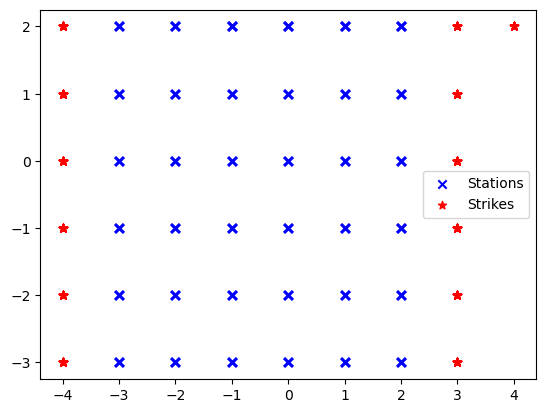

In [22]:
plt.figure()

plt.scatter(df_picks['lon'], df_picks['lat'], c='b', marker='x', label='Stations')
plt.scatter(df_picks['ev_lon'], df_picks['ev_lat'], c='r', marker='*', label='Strikes')
plt.legend()
plt.show()

## Distance vs Time plot with error bars

In [23]:
all_distances = df_picks['distance_to_source'].unique()
all_distances.sort()

df_picks['dt'] = None
df_picks['group'] = None
# Identify the rows where x is 0

for k, exp in enumerate(df_picks['experiment'].unique()):
    
    selected_df_exp = df_picks[(df_picks['experiment']==exp)]
    first_station = selected_df_exp['distance_to_source'].min()
    
    selected_df_exp = df_picks[(df_picks['distance_to_source'] == first_station) & (df_picks['experiment']==exp)]
    
    # print(exp)
    
    min_time = selected_df_exp['datetime'].values
    # print("\t", len(min_time))

    # Subtract these datetime values from the datetime values of rows where x is greater than 0
    count = 0
    for j, times in enumerate(min_time):
        for i, row in df_picks.iterrows():
            if abs(row['datetime'] - min_time[j]) < 0.1: # a bit rough XXX 
                df_picks.at[i, 'dt'] = row['datetime'] - min_time[j]
                df_picks.at[i, 'group'] = j
                # print(j)
                count += 1
    # print('\t', count)

print("Number of all picks collected:", len(df_picks))
print("Number of unique experiments:", len(df_picks['experiment'].unique()))
print("Number of unique stations:", len(df_picks['sta'].unique()))

df_picks.head()

Number of all picks collected: 375
Number of unique experiments: 13
Number of unique stations: 36


,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,dt,group
0,2024-06-06T17:37:17.564180Z,1,8,SH,39175,R,2.0,-4.0,2.0,-3.0,0,0,1.0,0.0,0
1,2024-06-06T17:37:17.568160Z,1,8,SH,33345,R,2.0,-4.0,2.0,-2.0,0,0,2.0,0.00398,0
2,2024-06-06T17:37:17.572070Z,1,8,SH,31500,R,2.0,-4.0,2.0,-1.0,0,0,3.0,0.00789,0
3,2024-06-06T17:37:17.575860Z,1,8,SH,33116,R,2.0,-4.0,2.0,0.0,0,0,4.0,0.01168,0
4,2024-06-06T17:37:17.579950Z,1,8,SH,31786,R,2.0,-4.0,2.0,1.0,0,0,5.0,0.01577,0


#### Sanity test plot

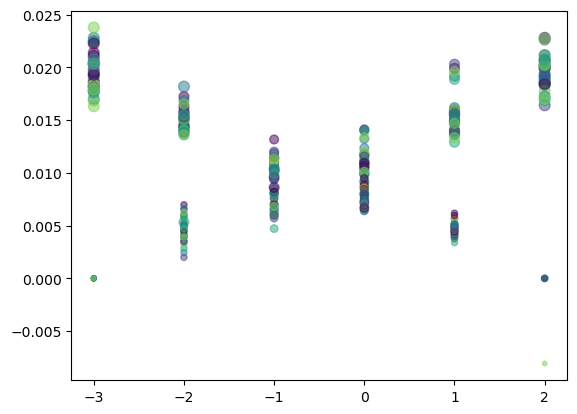

In [24]:
plt.figure()
# plt.scatter(df_picks['distance_to_source'], df_picks['dt'], s=df_picks['distance_to_source']*10, c=df_picks['group'], cmap='viridis', alpha=0.5)
plt.scatter(df_picks['lon'], df_picks['dt'], s=df_picks['distance_to_source']*10, c=df_picks['group'], cmap='viridis', alpha=0.5)
plt.show()

In [40]:
# grouped = df_picks[df_picks['experiment'] == 8]
# plt.figure()
# # plt.scatter(df_picks['distance_to_source'], df_picks['dt'], s=df_picks['distance_to_source']*10, c=df_picks['group'], cmap='viridis', alpha=0.5)
# plt.scatter(grouped['lon'], grouped['dt'], s=grouped['distance_to_source']*10, c=grouped['group'], cmap='viridis', alpha=0.5)
# plt.show()

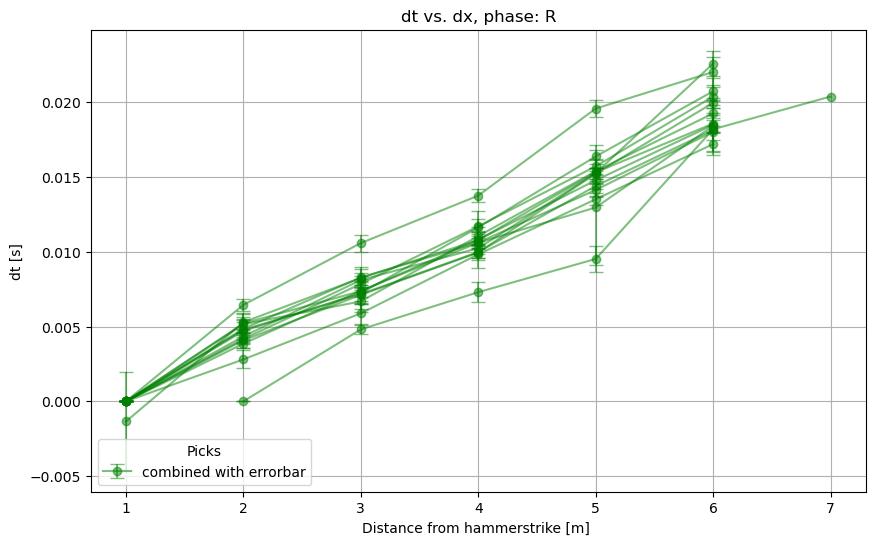

In [26]:
plt.figure(figsize=(10, 6))

for _, exp in enumerate(df_picks['experiment'].unique()):

    df_group = df_picks[df_picks['experiment'] == exp]
    grouped = df_group.groupby('distance_to_source')['dt'].agg(['mean', 'std']).reset_index()

    plt.errorbar(grouped['distance_to_source'], grouped['mean'], yerr=grouped['std'], color='g', fmt='o', linestyle='-', capsize=5, alpha=0.5, label='combined with errorbar')

# Create a custom legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

plt.xlabel('Distance from hammerstrike [m] ')
plt.ylabel('dt [s]')
plt.title('dt vs. dx, phase: %s' %phase)
plt.grid(True)
plt.show()

# Export with x, y, dist, mean, and std
# grouped_extended = pd.merge(grouped, df_picks[['distance_to_source', 'lon', 'lat', 'sta', 'experiment']].drop_duplicates(), on='distance_to_source', how='left')
# grouped_extended.to_csv(os.path.join(save_path, f"grouped_mean_std_HS{number_hammer_strike:02d}.csv"))

In [83]:
df_group

,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,dt,group
305,2024-06-06T18:03:12.409960Z,1,49,SH,34071,S,2.0,4.0,2.0,2.0,0,0,2.0,0.0,0
306,2024-06-06T18:03:12.415210Z,1,49,SH,31786,S,2.0,4.0,2.0,1.0,0,0,3.0,0.00525,0
307,2024-06-06T18:03:12.417510Z,1,49,SH,33116,S,2.0,4.0,2.0,0.0,0,0,4.0,0.00755,0
308,2024-06-06T18:03:12.420790Z,1,49,SH,31500,S,2.0,4.0,2.0,-1.0,0,0,5.0,0.01083,0
309,2024-06-06T18:03:12.424080Z,1,49,SH,33345,S,2.0,4.0,2.0,-2.0,0,0,6.0,0.01412,0
310,2024-06-06T18:03:12.428670Z,1,49,SH,39175,S,2.0,4.0,2.0,-3.0,0,0,7.0,0.01871,0
311,2024-06-06T18:03:13.221860Z,1,49,SH,34071,S,2.0,4.0,2.0,2.0,0,0,2.0,0.0,1
312,2024-06-06T18:03:13.227310Z,1,49,SH,31786,S,2.0,4.0,2.0,1.0,0,0,3.0,0.00545,1
313,2024-06-06T18:03:13.229770Z,1,49,SH,33116,S,2.0,4.0,2.0,0.0,0,0,4.0,0.00791,1
314,2024-06-06T18:03:13.231950Z,1,49,SH,31500,S,2.0,4.0,2.0,-1.0,0,0,5.0,0.01009,1


   lon  mean_dt    std_dt
0 -3.0  0.02038       NaN
1 -2.0  0.01819       NaN
2 -1.0  0.00952  0.000876
3  0.0   0.0073  0.000674
4  1.0  0.00481  0.000331
5  2.0      0.0  0.000000


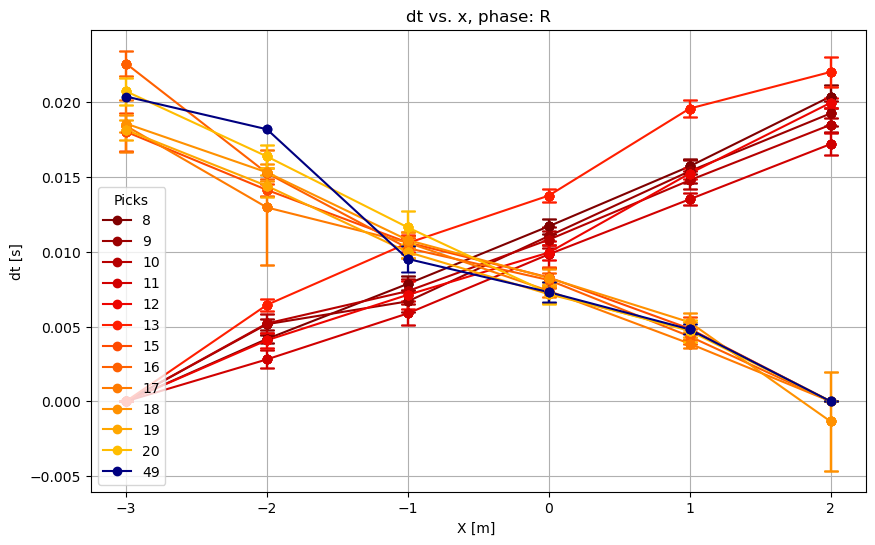

In [27]:
plt.figure(figsize=(10, 6))

cmap = plt.get_cmap('jet_r')  # You can choose other colormaps like 'plasma', 'inferno', etc.
norm = plt.Normalize(df_picks['experiment'].min(), df_picks['experiment'].max())

collect_picks = []

for _, exp in enumerate(df_picks['experiment'].unique()):
    
    df_group = df_picks[df_picks['experiment'] == exp]
    grouped = df_group.groupby('lon')['dt'].agg(['mean', 'std']).reset_index()
    grouped.rename(columns={'mean': 'mean_dt', 'std': 'std_dt'}, inplace=True)

    df_group = df_group.merge(grouped, on=['lon'], how='left')

    plt.plot(grouped['lon'], grouped['mean_dt'], 'o-', label=exp,  color=cmap(norm(exp)))
    
    for i, row in df_group.iterrows():
        collect_picks.append([row['datetime'], row['session'],row['experiment'], row['net'], row['sta'], row['phase'], row['ev_lat'], row['ev_lon'], row['lat'], row['lon'], row['elev'], row['depth'], row['distance_to_source'], row['dt'], row['group'], row['mean_dt'], row['std_dt']])
        plt.errorbar(row['lon'], row['mean_dt'], yerr=row['std_dt'], fmt='o',  linestyle='-',capsize=5,  color=cmap(norm(exp)))

df_big = pd.DataFrame(collect_picks, columns = ['datetime', 'session', 'experiment', 'net', 'sta', 'phase', 'ev_lat',
       'ev_lon', 'lat', 'lon', 'elev', 'depth', 'distance_to_source', 'dt',
       'group', 'mean', 'std']) 

print(grouped)

# Create a custom legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

plt.xlabel('X [m] ')
plt.ylabel('dt [s]')
plt.title('dt vs. x, phase: %s' %phase)

plt.grid(True)
plt.show()

df_big.to_csv(os.path.join(save_path, f"combined_strikes_with_mean_std.csv"))


### Contour plot (only works if HS come from one side)

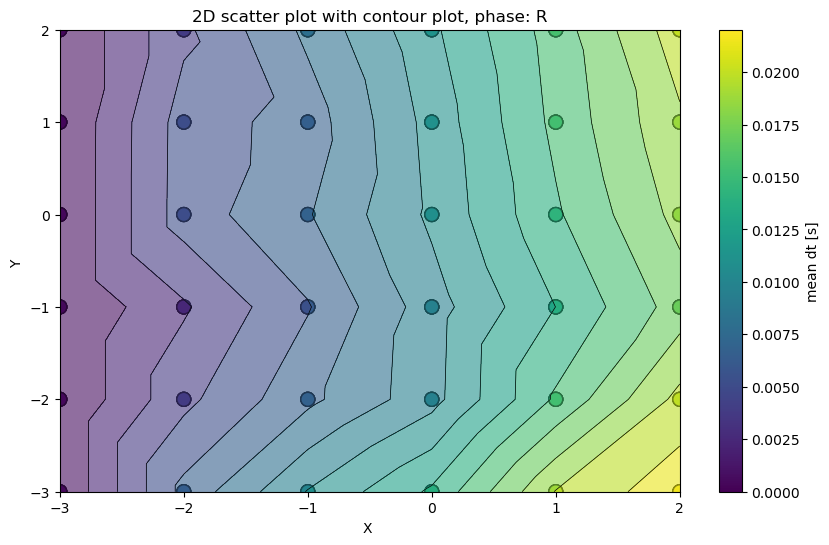

In [28]:
selected_df = df_big[df_big['ev_lon'] < 0] # so that we only get the mean dt from one side of the strike

# Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(selected_df['lon'], selected_df['lat'], c=selected_df['mean'], cmap='viridis', s=100, edgecolor='k')

# Add a colorbar
colorbar = plt.colorbar(scatter)
colorbar.set_label('mean dt [s]')

# # Create the contour plot
contour = plt.tricontour(selected_df['lon'], selected_df['lat'], selected_df['mean'], levels=14, linewidths=0.5, colors='k')
contourf = plt.tricontourf(selected_df['lon'], selected_df['lat'], selected_df['mean'], levels=14, cmap='viridis', alpha=0.6)

# Add labels and title
plt.xlabel('X ')
plt.ylabel('Y ')
plt.title('2D scatter plot with contour plot, phase: %s' %phase)

# Show the plot
plt.show()





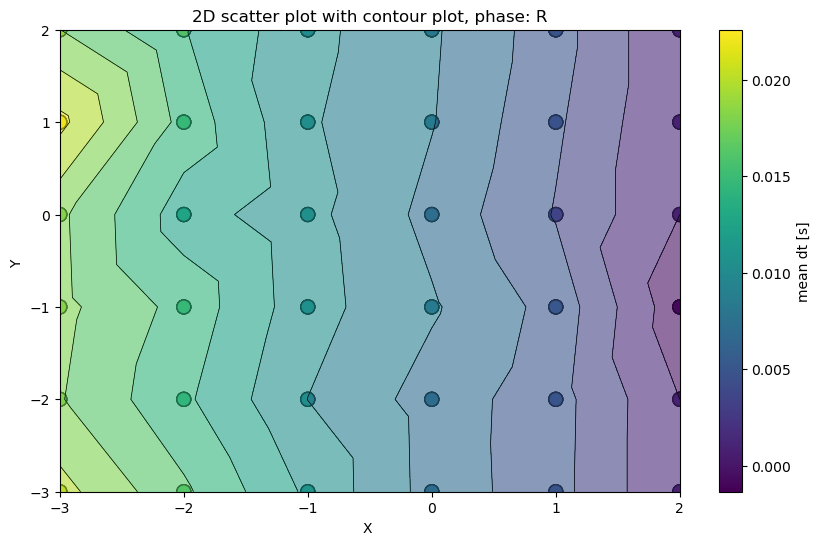

In [29]:
selected_df = df_big[df_big['ev_lon'] > 0] # so that we only get the mean dt from one side of the strike

# Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(selected_df['lon'], selected_df['lat'], c=selected_df['mean'], cmap='viridis', s=100, edgecolor='k')

# Add a colorbar
colorbar = plt.colorbar(scatter)
colorbar.set_label('mean dt [s]')

# # Create the contour plot
contour = plt.tricontour(selected_df['lon'], selected_df['lat'], selected_df['mean'], levels=14, linewidths=0.5, colors='k')
contourf = plt.tricontourf(selected_df['lon'], selected_df['lat'], selected_df['mean'], levels=14, cmap='viridis', alpha=0.6)

# Add labels and title
plt.xlabel('X ')
plt.ylabel('Y ')
plt.title('2D scatter plot with contour plot, phase: %s' %phase)

# Show the plot
plt.show()